In [13]:
from typing import TypedDict, List
from langgraph.graph import StateGraph,START, END
from IPython.display import Image,display

# This is our Agent's "Notepad"
class HelpdeskState(TypedDict):
    user_query: str
    category: str
    steps_taken: List[str]
    is_resolved: bool

In [14]:
def classify_ticket(state: HelpdeskState):
    # In reality, you'd call an LLM here. Let's mock it.
    query = state["user_query"]
    print(f"Classifying: {query}")
    
    # We return ONLY the parts of the state we want to update
    return {
        "category": "Networking", 
        "steps_taken": ["Classified ticket as Networking"]
    }

def troubleshoot_vpn(state: HelpdeskState):
    print("Running VPN Diagnostics...")
    return {
        "is_resolved": True,
        "steps_taken": ["Ran VPN diagnostic tool - success"]
    }

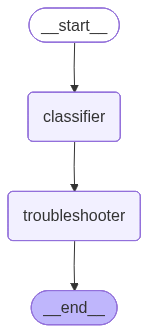

In [15]:
# Initialize the graph with our TypedDict
workflow = StateGraph(HelpdeskState)

# Add our nodes
workflow.add_node("classifier", classify_ticket)
workflow.add_node("troubleshooter", troubleshoot_vpn)

# Define the flow
workflow.set_entry_point("classifier")
workflow.add_edge(START,"classifier")
workflow.add_edge("classifier", "troubleshooter")
workflow.add_edge("troubleshooter", END)

# Compile into an executable app
agent = workflow.compile()

graph_image = agent.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [16]:
# Run the agent with an initial state
initial_state = {
    "user_query": "I can't connect to the corporate VPN.",
    "category": "",
    "steps_taken": [],
    "is_resolved": False
}

final_state = agent.invoke(initial_state)
print("\nFinal Agent State:")
print(final_state)

Classifying: I can't connect to the corporate VPN.
Running VPN Diagnostics...

Final Agent State:
{'user_query': "I can't connect to the corporate VPN.", 'category': 'Networking', 'steps_taken': ['Ran VPN diagnostic tool - success'], 'is_resolved': True}
